In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import ast
import seaborn as sns

# loading data
dataset = load_dataset('Lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Kimo Store\AppData\Local\Programs\Python\Python38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Filter for US Analyst roles

In [2]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

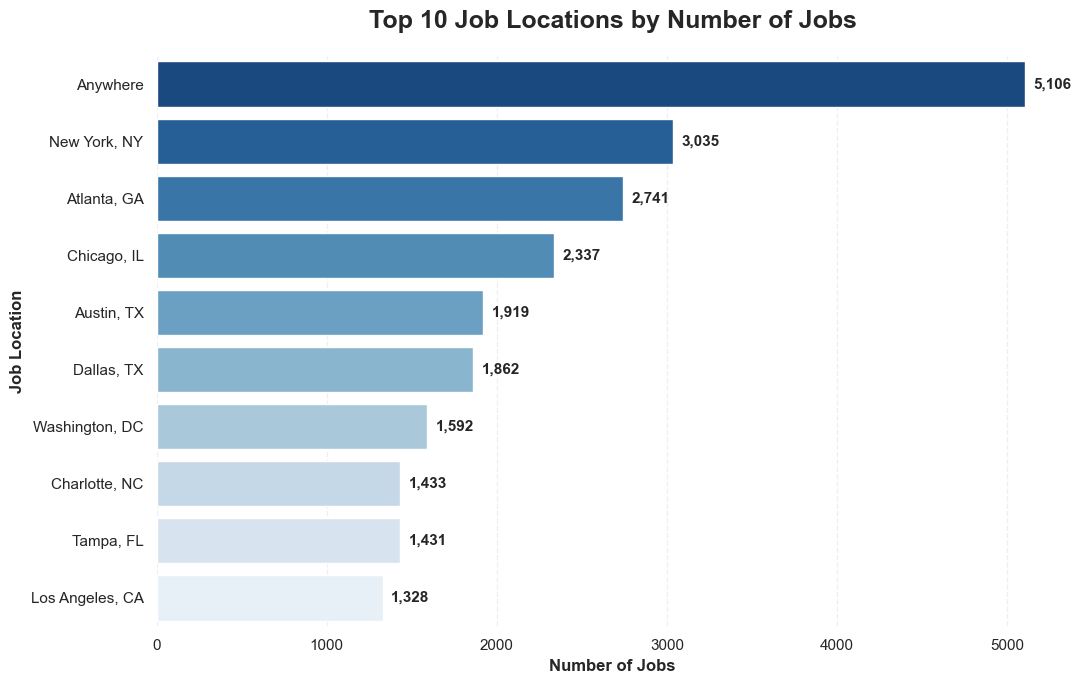

In [4]:
df_plot = (
    df_DA_US['job_location']
    .value_counts()
    .head(10)
    .sort_values(ascending=False)
    .to_frame(name='count')
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 7))

colors = sns.color_palette("Blues_r", n_colors=len(df_plot))

ax = sns.barplot(
    data=df_plot,
    x='count',
    y=df_plot.index,
    palette=colors,
    hue=df_plot.index,
    legend=False
)


for i, value in enumerate(df_plot['count']):
    ax.text(
        value + df_plot['count'].max() * 0.01,
        i,
        f'{value:,}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Top 10 Job Locations by Number of Jobs',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Number of Jobs', fontsize=12, fontweight='bold')
plt.ylabel('Job Location', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', visible=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


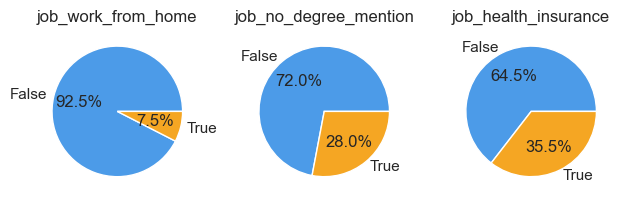

In [5]:
requirment_needed =df_DA_US[['job_work_from_home','job_no_degree_mention','job_health_insurance']]
fig , ax =plt.subplots(1,3)

for i,job in enumerate (requirment_needed):
    job_plot = df_DA_US[job].value_counts()
    job_plot.plot(kind='pie',ax=ax[i],autopct='%1.1f%%',title=job,ylabel='',colors=['#4C9BE8','#F5A623'])

fig.tight_layout()

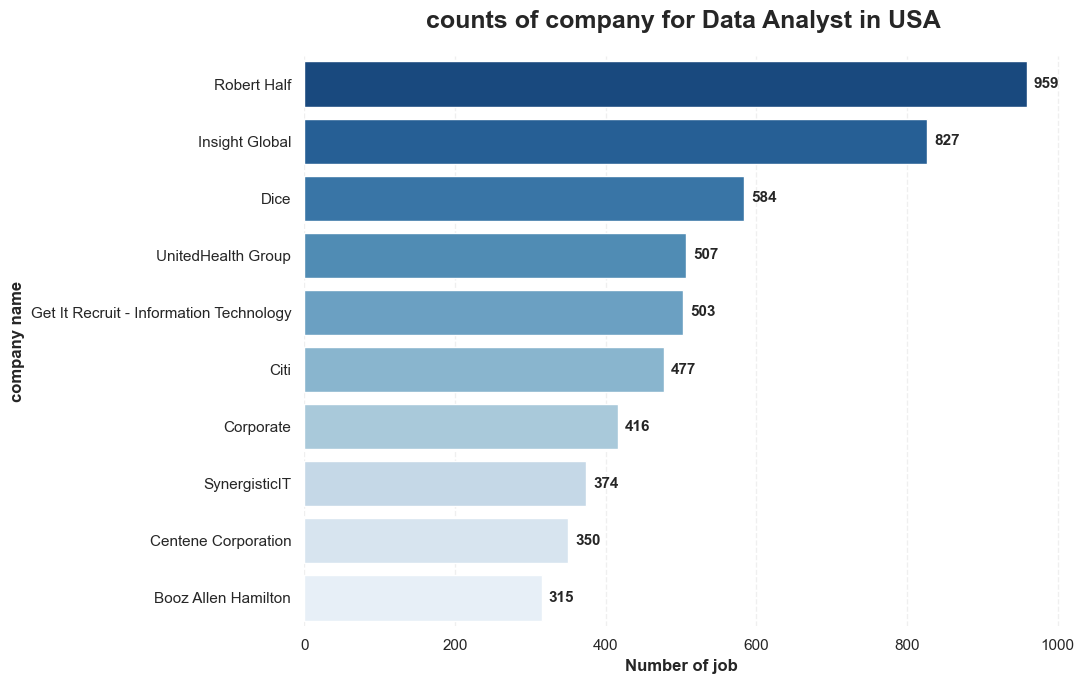

In [6]:
df_plot = (
    df_DA_US['company_name']
    .value_counts()
    .head(10)
    .sort_values(ascending=False)
    .to_frame(name='count')
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 7))

colors = sns.color_palette("Blues_r", n_colors=len(df_plot))

ax = sns.barplot(
    data=df_plot,
    x='count',
    y=df_plot.index,
    palette=colors,
    hue=df_plot.index,
    legend=False
)


for i, value in enumerate(df_plot['count']):
    ax.text(
        value + df_plot['count'].max() * 0.01,
        i,
        f'{value:,}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'counts of company for Data Analyst in USA',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Number of job ', fontsize=12, fontweight='bold')
plt.ylabel('company name', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', visible=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


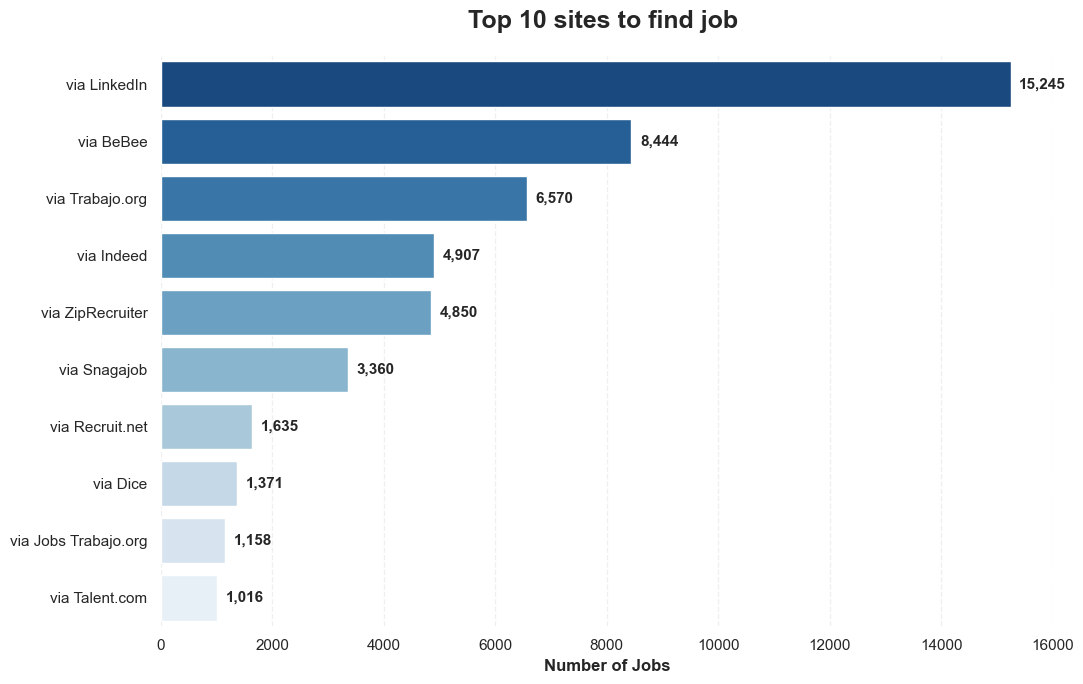

In [7]:
df_plot = (
    df_DA_US['job_via']
    .value_counts()
    .head(10)
    .sort_values(ascending=False)
    .to_frame(name='count')
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 7))

colors = sns.color_palette("Blues_r", n_colors=len(df_plot))

ax = sns.barplot(
    data=df_plot,
    x='count',
    y=df_plot.index,
    palette=colors,
    hue=df_plot.index,
    legend=False
)


for i, value in enumerate(df_plot['count']):
    ax.text(
        value + df_plot['count'].max() * 0.01,
        i,
        f'{value:,}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Top 10 sites to find job ',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Number of Jobs', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', visible=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()
